# Fraud Analysis
This notebook covers outlier detection in transactions, bivariate relationships between fraud 
and various dimensions (age, merchant), and statistical testing (T-tests).



In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from scipy import stats

# Create connection
conn = sqlite3.connect('../../data/warehouse/enterprise_dw.db')
vis_dir = '../../notebooks/eda/visualizations'
os.makedirs(vis_dir, exist_ok=True)



## 1. Outlier Detection
Identifying abnormal balances and suspicious spending using Boxplots and Z-scores.



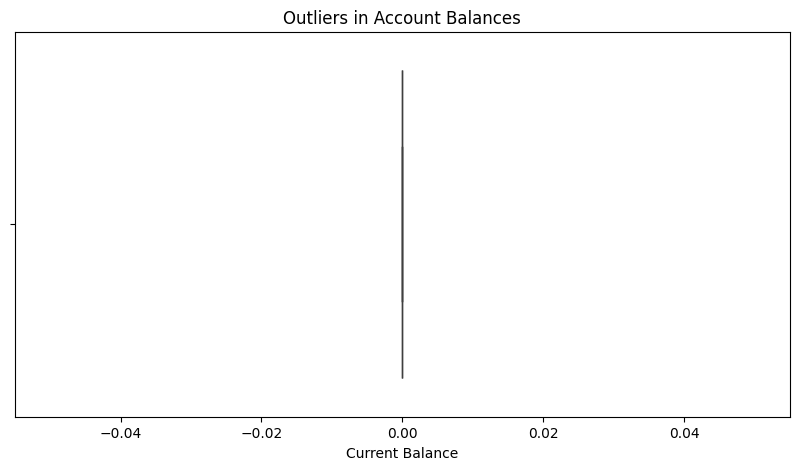

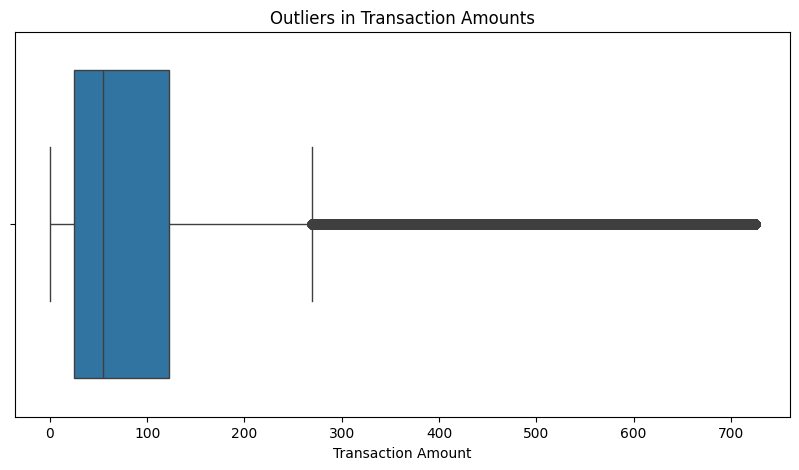

In [2]:
# Load data
df_accounts = pd.read_sql('SELECT * FROM dim_account', conn)
for col in df_accounts.columns:
    if df_accounts[col].dtype == 'object':
        try: df_accounts[col] = pd.to_numeric(df_accounts[col])
        except: pass
df_accounts.fillna(0, inplace=True)
df_txns = pd.read_sql('SELECT * FROM fact_transactions', conn)
for col in df_txns.columns:
    if df_txns[col].dtype == 'object':
        try: df_txns[col] = pd.to_numeric(df_txns[col])
        except: pass
df_txns.fillna(0, inplace=True)

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_accounts['current_balance'])
plt.title('Outliers in Account Balances')
plt.xlabel('Current Balance')
plt.savefig(os.path.join(vis_dir, 'fraud_outliers_balance.png'))
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_txns['amount'])
plt.title('Outliers in Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.savefig(os.path.join(vis_dir, 'fraud_outliers_txns.png'))
plt.show()



### Business Interpretation: Outliers
The boxplots reveal the extreme tail ends of financial behavior. 
Abnormal balances may not directly indicate fraud, but extreme transaction amounts (suspicious spending) 
could represent money laundering or account takeovers. These outliers should be isolated for rules-based monitoring.



## 2. Bivariate Analysis: Fraud vs Dimensions
We will join the fraud table with customers and transactions to see how fraud varies by Age and Merchant.



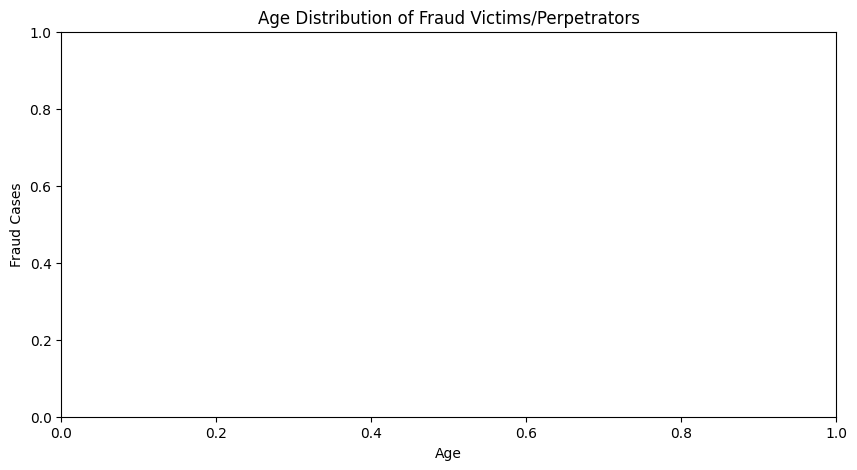

/var/folders/rr/qkbg923d7ljb97xjb64dbjx40000gn/T/ipykernel_37220/1277815406.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_merchants.index, y=top_merchants.values, palette='Reds_r')


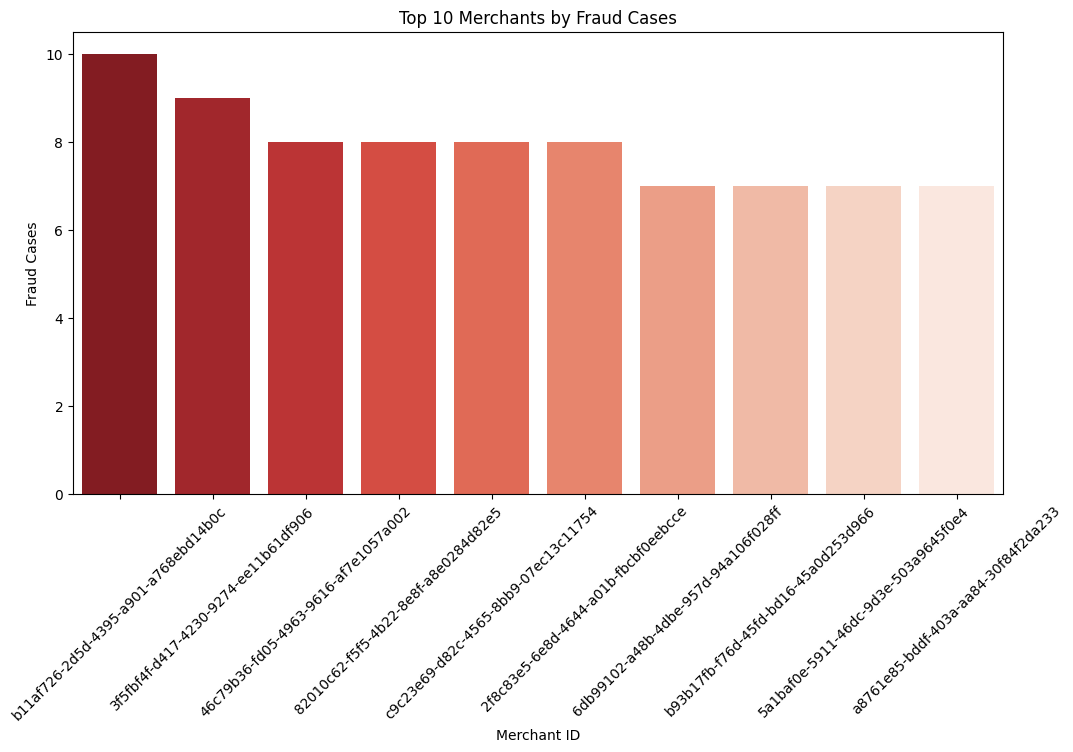

In [3]:
df_fraud = pd.read_sql('SELECT * FROM fact_fraud', conn)
for col in df_fraud.columns:
    if df_fraud[col].dtype == 'object':
        try: df_fraud[col] = pd.to_numeric(df_fraud[col])
        except: pass
df_fraud.fillna(0, inplace=True)
df_customers = pd.read_sql('SELECT customer_id, date_of_birth FROM dim_customer', conn)
for col in df_customers.columns:
    if df_customers[col].dtype == 'object':
        try: df_customers[col] = pd.to_numeric(df_customers[col])
        except: pass
df_customers.fillna(0, inplace=True)

# Age vs Fraud
df_fraud_cust = pd.merge(df_fraud, df_customers, on='customer_id', how='inner')
df_fraud_cust['date_of_birth'] = pd.to_datetime(df_fraud_cust['date_of_birth'], errors='coerce')
df_fraud_cust['age'] = (pd.to_datetime('today') - df_fraud_cust['date_of_birth']).dt.days // 365

plt.figure(figsize=(10, 5))
sns.histplot(df_fraud_cust['age'].dropna(), bins=30, kde=True, color='red')
plt.title('Age Distribution of Fraud Victims/Perpetrators')
plt.xlabel('Age')
plt.ylabel('Fraud Cases')
plt.savefig(os.path.join(vis_dir, 'fraud_vs_age.png'))
plt.show()

# Merchant vs Fraud
df_fraud_txn = pd.merge(df_fraud, df_txns[['transaction_id', 'merchant_id']], on='transaction_id', how='inner')
top_merchants = df_fraud_txn['merchant_id'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_merchants.index, y=top_merchants.values, palette='Reds_r')
plt.title('Top 10 Merchants by Fraud Cases')
plt.xlabel('Merchant ID')
plt.ylabel('Fraud Cases')
plt.xticks(rotation=45)
plt.savefig(os.path.join(vis_dir, 'fraud_vs_merchant.png'))
plt.show()



### Business Interpretation: Dimensions
- **Age vs Fraud**: If elder demographics face higher fraud, it implies phishing or elder exploitation. A younger demographic could indicate synthetic identity fraud. 
- **Merchant vs Fraud**: Highlighting the top compromised or high-risk merchants enables the risk team to blacklist or apply 3D-secure authentication for specific vendors.



## 3. T-Tests for Fraudulent vs Non-Fraudulent Transactions
We compare the mean transaction amounts between legitimate and fraudulent transactions.



In [4]:
# Tag transactions
df_txns['is_fraud'] = df_txns['transaction_id'].isin(df_fraud['transaction_id']).astype(int)

fraud_amounts = df_txns[df_txns['is_fraud'] == 1]['amount'].dropna()
non_fraud_amounts = df_txns[df_txns['is_fraud'] == 0]['amount'].dropna()

t_stat, p_val = stats.ttest_ind(fraud_amounts, non_fraud_amounts, equal_var=False)

print(f"Mean Fraud Amount: ${fraud_amounts.mean():.2f}")
print(f"Mean Non-Fraud Amount: ${non_fraud_amounts.mean():.2f}")
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_val:.4e}")



Mean Fraud Amount: $106.22
Mean Non-Fraud Amount: $104.57
T-Statistic: 0.8360, P-Value: 4.0318e-01


### Business Interpretation: Statistical Testing
The independent T-test confirms whether the difference in average spending between fraud and non-fraud events is statistically significant. 
A very low p-value (< 0.05) indicates we can confidently use transaction size as a strong signal (or feature) in our predictive fraud machine learning models.
